In [19]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [20]:
stud_perf = pd.read_csv(r'D:\AI & ML\Machine_Learning_19\Dataset\Student_Performance.csv')


# EDA

In [21]:
stud_perf.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [22]:
stud_perf.shape

(10000, 6)

In [23]:
stud_perf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [24]:
stud_perf.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [25]:
stud_perf.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

# Feature Endcoding-

In [26]:
stud_perf.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [27]:
from sklearn.preprocessing import LabelEncoder
stud_perf['Extracurricular Activities'] = LabelEncoder().fit_transform(stud_perf['Extracurricular Activities'])
stud_perf.head(4)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0


In [28]:
Independent = stud_perf.drop('Performance Index',axis=1)
Dependent = stud_perf['Performance Index']
Independent

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [29]:
Dependent

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64

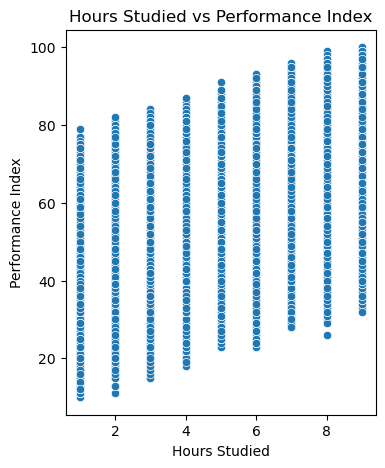

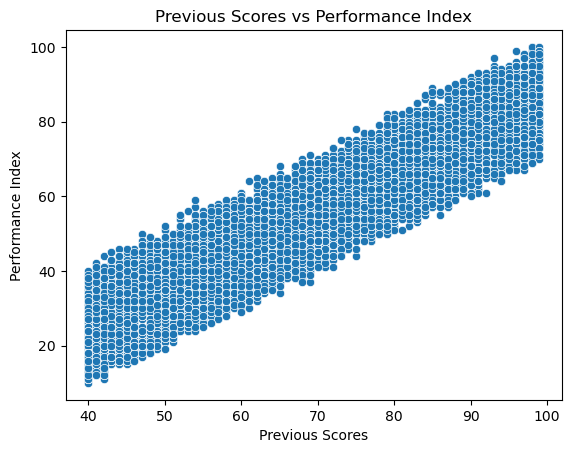

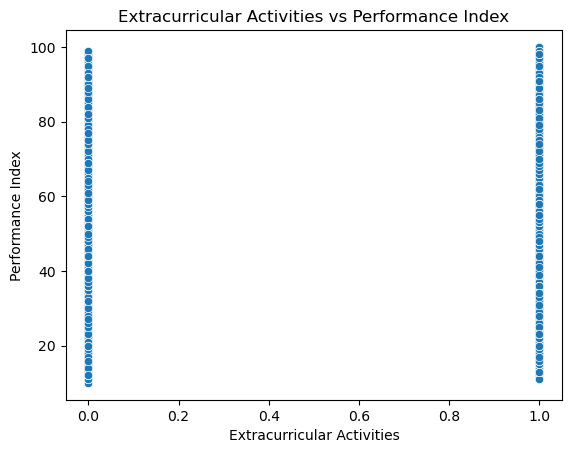

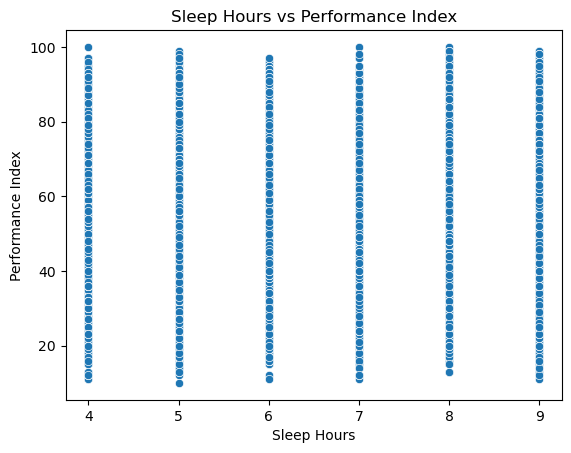

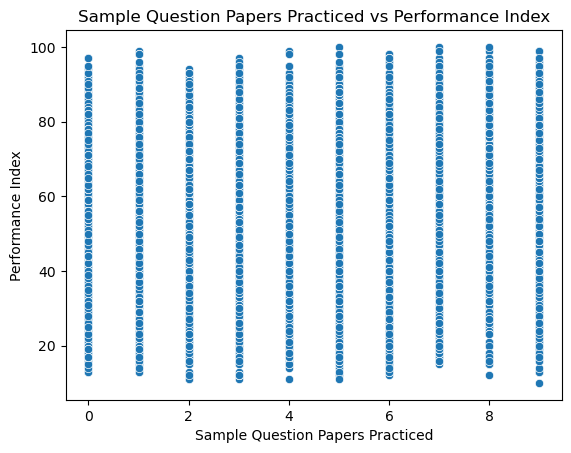

In [30]:
plt.figure(figsize=(4,5))

features = ['Hours Studied','Previous Scores','Extracurricular Activities',
            'Sleep Hours','Sample Question Papers Practiced']

for col in features:
    sns.scatterplot(x=stud_perf[col], y=stud_perf['Performance Index'])
    plt.title(f"{col} vs Performance Index")
    plt.show()

plt.show()

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(Independent,Dependent,test_size=0.3, random_state=42)

In [32]:
from sklearn.linear_model import LinearRegression
model_train = LinearRegression().fit(X_train,Y_train)

In [34]:
predict = model_train.predict(X_test)
predict

array([54.74728554, 22.61884434, 47.93665124, ..., 33.42451751,
       67.92578967, 31.20587077])

In [40]:
from sklearn.metrics import r2_score,accuracy_score,mean_absolute_error

print('R2score = ',r2_score(Y_test,predict)*100)
print('Absolute Error = ',mean_absolute_error(Y_test,predict))


R2score =  98.90110607021137
Absolute Error =  1.609043756404523


In [ ]:
import pickle

with open(r'Student_performence_ind.pkl','wb') as file:
    pickle.dump(model_train,file)